# 03 — Catalyst deactivation with MMRM repeated-measures covariance

Catalyst activity measured over repeated reaction cycles is correlated
within a catalyst unit. A mixed model for repeated measures (MMRM)
directly models the within-unit residual covariance. Here we compare a
standard formulation with a stabilized formulation using AR(1)
covariance across six ordered cycles.

## Learning objectives

You will:

1. generate deterministic longitudinal activity data;
2. understand why visit order is part of the covariance model;
3. fit an MMRM with fixed formulation, cycle, and interaction effects;
4. inspect the fitted AR(1) covariance and Satterthwaite label;
5. translate interaction coefficients into deactivation slopes; and
6. state missingness, covariance, and mechanistic limitations.

## MMRM versus the earlier LMM

Notebook 01 used a random intercept to represent shared batch variation.
Here the central question is the pattern of residual dependence across
ordered cycles. The dedicated MMRM backend uses one within-catalyst
covariance block and, in the current reference path, does not combine
that block with formula random effects.

In [1]:
import importlib
import logging
from pprint import pprint

import numpy as np

import pymixef

# Keep first-run Matplotlib font-cache status out of committed showcase output.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

print("PyMixEF version:", pymixef.__version__)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 10,
        "axes.titleweight": "semibold",
    }
)

PyMixEF version: 0.1.1


## 1. Generate longitudinal deactivation data

Twenty-four catalyst units are split evenly between two formulations.
Each unit is observed at cycles 0 through 5. The stabilized formulation
has a less negative deactivation slope. Synthetic errors follow an AR(1)
covariance with correlation 0.62 and marginal SD 1.7.

In [2]:
rng = np.random.default_rng(20260725)

n_catalysts = 24
cycle_levels = np.arange(6, dtype=float)
residual_sd = 1.7
residual_rho = 0.62
generating_covariance = residual_sd**2 * residual_rho ** np.abs(
    np.subtract.outer(cycle_levels, cycle_levels)
)

formulation_by_catalyst = np.array(
    ["A-standard"] * (n_catalysts // 2) + ["B-stabilized"] * (n_catalysts // 2)
)

activity = []
formulation = []
cycle = []
catalyst_id = []

for catalyst_index, formulation_name in enumerate(formulation_by_catalyst):
    stabilized = formulation_name == "B-stabilized"
    mean_trajectory = (
        95.0
        - 2.5 * cycle_levels
        + (1.0 if stabilized else 0.0)
        + (0.9 * cycle_levels if stabilized else 0.0)
    )
    correlated_error = rng.multivariate_normal(
        np.zeros(len(cycle_levels)),
        generating_covariance,
    )
    activity.extend(mean_trajectory + correlated_error)
    formulation.extend([formulation_name] * len(cycle_levels))
    cycle.extend(cycle_levels)
    catalyst_id.extend([f"catalyst-{catalyst_index + 1:02d}"] * len(cycle_levels))

activity = np.asarray(activity)
formulation = np.asarray(formulation)
cycle = np.asarray(cycle)
catalyst_id = np.asarray(catalyst_id)

deactivation_data = {
    "activity": activity,
    "formulation": formulation,
    "cycle": cycle,
    "cycle_centered": cycle,  # cycle 0 is already a meaningful reference
    "catalyst_id": catalyst_id,
}

print("Rows:", len(activity))
print("Catalyst units:", len(set(catalyst_id.tolist())))
print("Cycle levels:", sorted(set(cycle.tolist())))

Rows: 144
Catalyst units: 24
Cycle levels: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


Compute raw mean trajectories as a data check. These summaries ignore
within-catalyst correlation and are not the MMRM estimates.

In [3]:
print(f"{'formulation':16s} {'cycle':>7s} {'raw mean activity':>20s}")
for formulation_name in sorted(set(formulation.tolist())):
    for cycle_value in cycle_levels:
        selected = (formulation == formulation_name) & (cycle == cycle_value)
        print(
            f"{formulation_name:16s} {cycle_value:7.0f} {float(np.mean(activity[selected])):20.3f}"
        )

formulation        cycle    raw mean activity
A-standard             0               95.490
A-standard             1               92.231
A-standard             2               89.817
A-standard             3               87.863
A-standard             4               84.934
A-standard             5               82.452
B-stabilized           0               94.809
B-stabilized           1               93.727
B-stabilized           2               92.185
B-stabilized           3               91.530
B-stabilized           4               89.842
B-stabilized           5               88.075


## 2. Declare the ordered residual covariance

`AR1(dimension=6, index="cycle", group="catalyst_id")` means:

- six ordered visit positions;
- one covariance block per catalyst unit;
- common marginal residual SD; and
- correlation that decays as \(ho^{|j-k|}\).

Numeric cycle labels are sorted ascending. PyMixEF archives the resolved
visit levels, times, and order source. For nonnumeric labels, an explicit
scientific order is required for AR(1), Toeplitz, ante-dependence, and
spatial structures.

In [4]:
ar1_residual = pymixef.covariance.AR1(
    dimension=len(cycle_levels),
    index="cycle",
    group="catalyst_id",
)

mmrm_model = pymixef.Model.from_formula(
    "activity ~ formulation * cycle_centered",
    residual=ar1_residual,
)

print(
    mmrm_model.explain(
        deactivation_data,
        engine="mmrm",
        method="reml",
    )
)

Formula: activity ~ formulation * cycle_centered
Response: activity (144 analysis rows)
Fixed design: X(144, 4), rank=4, columns=['Intercept', 'formulation[B-stabilized]', 'cycle_centered', 'formulation[B-stabilized]:cycle_centered']
Random designs:
  none
Excluded source rows: 0
Family: gaussian (identity link)
Engine: mmrm; method: reml
Compatibility: valid


## 3. Compile and inspect the fixed design

The alphabetically first formulation, `A-standard`, is the treatment
reference. Therefore:

- `Intercept` is standard-formulation activity at cycle 0;
- `cycle_centered` is the standard deactivation slope;
- `formulation[B-stabilized]` is the cycle-0 difference; and
- the interaction is the difference in slopes.

In [5]:
mmrm_plan = mmrm_model.compile(
    deactivation_data,
    engine="mmrm",
    method="reml",
    maxiter=2000,
    tolerance=1e-12,
)

print(mmrm_plan.explain())
pprint(
    {
        "fixed_columns": mmrm_plan.matrices.fixed_names,
        "analysis_rows": mmrm_plan.matrices.audit.analysis_rows,
        "excluded_rows": mmrm_plan.matrices.audit.excluded_rows,
        "factor_levels": dict(mmrm_plan.matrices.factor_levels),
    }
)

Formula: activity ~ formulation * cycle_centered
Response: activity (144 analysis rows)
Fixed design: X(144, 4), rank=4, columns=['Intercept', 'formulation[B-stabilized]', 'cycle_centered', 'formulation[B-stabilized]:cycle_centered']
Random designs:
  none
Excluded source rows: 0
Family: gaussian (identity link)
Engine: mmrm; method: reml
Model IR: 36b7c17e58256720f1069a0f95415b64d7dbfcf37356f41834674405b590bb0a
Data audit: 144 input, 144 analysis, 0 excluded; reasons={'DATA-RETAINED-001': 144}
{'analysis_rows': 144,
 'excluded_rows': 0,
 'factor_levels': {'formulation': ('A-standard', 'B-stabilized')},
 'fixed_columns': ('Intercept',
                   'formulation[B-stabilized]',
                   'cycle_centered',
                   'formulation[B-stabilized]:cycle_centered')}


## 4. Fit the MMRM

REML estimates covariance parameters. The default denominator degrees
of freedom option is the explicitly labeled Satterthwaite delta method.
Exact Kenward–Roger inference is not claimed.

In [6]:
mmrm_fit = mmrm_plan.fit()
print(mmrm_fit.summary())

PyMixEF fit (mmrm, reml)
Observations: 144
Objective: 257.9059717
Log likelihood: -257.9059717
Convergence: converged
Parameters:
  Intercept                                  95.347357
  formulation[B-stabilized]                 -0.40637659
  cycle_centered                            -2.5921091
  formulation[B-stabilized]:cycle_centered   1.2533132
  residual_sd                                1.8480618
  ar1_correlation                            0.66524351


## 5. Check convergence, inference labeling, and visit order

Visit ordering is scientific model state, not a display preference.
The archived evidence makes it possible to verify that covariance
adjacency did not depend on input row order.

In [7]:
pprint(
    {
        "status": mmrm_fit.convergence.status,
        "trustworthy": mmrm_fit.convergence.trustworthy,
        "scaled_gradient_inf_norm": (mmrm_fit.convergence.scaled_gradient_inf_norm),
        "hessian_positive_definite": (mmrm_fit.convergence.hessian.positive_definite),
        "warning_codes": [warning.code for warning in mmrm_fit.convergence.warnings],
        "degrees_of_freedom_method": (mmrm_fit.extra["degrees_of_freedom_method"]),
        "visit_levels": mmrm_fit.extra["visit_levels"],
        "visit_times": mmrm_fit.extra["visit_times"],
        "visit_order_source": mmrm_fit.extra["visit_order_source"],
    }
)

assert mmrm_fit.convergence.trustworthy

{'degrees_of_freedom_method': 'Satterthwaite delta-method',
 'hessian_positive_definite': True,
 'scaled_gradient_inf_norm': 5.684341857518352e-06,
 'status': 'converged',
 'trustworthy': True,
 'visit_levels': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0],
 'visit_order_source': 'ascending-explicit-visit-times',
 'visit_times': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0],
 'warning_codes': []}


## 6. Convert coefficients into formulation trajectories

The interaction changes the deactivation slope. We calculate fitted
fixed-effect trajectories at each cycle. These are population means,
not catalyst-specific predictions.

In [8]:
parameters = mmrm_fit.parameters
standard_intercept = parameters["Intercept"]
standard_slope = parameters["cycle_centered"]
stabilized_intercept = standard_intercept + parameters["formulation[B-stabilized]"]
stabilized_slope = standard_slope + parameters["formulation[B-stabilized]:cycle_centered"]

assert standard_slope < 0.0 and stabilized_slope < 0.0
assert stabilized_slope > standard_slope, "Stabilization should slow deactivation."
assert stabilized_intercept + stabilized_slope * cycle_levels[-1] > (
    standard_intercept + standard_slope * cycle_levels[-1]
)

print("Estimated standard slope:", round(standard_slope, 3), "activity/cycle")
print(
    "Estimated stabilized slope:",
    round(stabilized_slope, 3),
    "activity/cycle",
)
print(
    "Slope difference (stabilized - standard):",
    round(stabilized_slope - standard_slope, 3),
)

print(f"\n{'cycle':>5s} {'standard':>12s} {'stabilized':>12s} {'difference':>12s}")
for cycle_value in cycle_levels:
    standard_mean = standard_intercept + standard_slope * cycle_value
    stabilized_mean = stabilized_intercept + stabilized_slope * cycle_value
    print(
        f"{cycle_value:5.0f} "
        f"{standard_mean:12.3f} "
        f"{stabilized_mean:12.3f} "
        f"{stabilized_mean - standard_mean:12.3f}"
    )

Estimated standard slope: -2.592 activity/cycle
Estimated stabilized slope: -1.339 activity/cycle
Slope difference (stabilized - standard): 1.253

cycle     standard   stabilized   difference
    0       95.347       94.941       -0.406
    1       92.755       93.602        0.847
    2       90.163       92.263        2.100
    3       87.571       90.925        3.354
    4       84.979       89.586        4.607
    5       82.387       88.247        5.860


### Figure: observed and fitted deactivation trajectories

Observed formulation means are shown with markers, while fixed-effect trajectories
show the fitted population trend over reaction cycles.

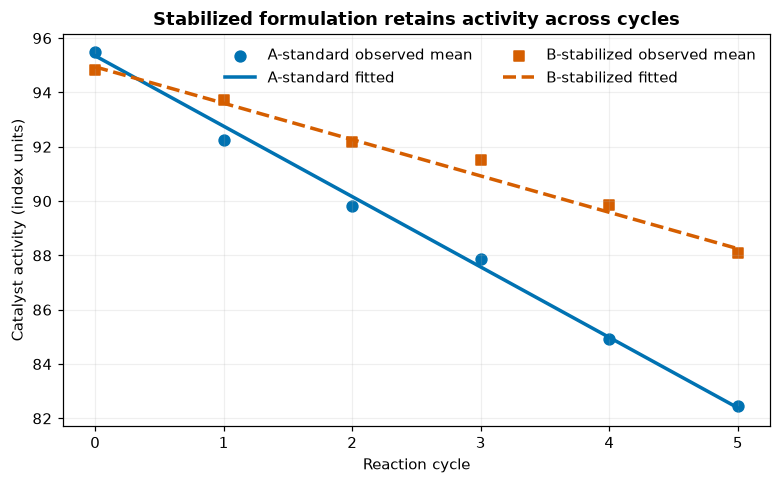

In [9]:
trajectory_styles = {
    "A-standard": ("#0072B2", "o", "-", standard_intercept, standard_slope),
    "B-stabilized": (
        "#D55E00",
        "s",
        "--",
        stabilized_intercept,
        stabilized_slope,
    ),
}

fig, ax = plt.subplots(figsize=(7.2, 4.5))
for formulation_name, (
    color,
    marker,
    line_style,
    intercept,
    slope,
) in trajectory_styles.items():
    raw_mean = np.array(
        [
            np.mean(activity[(formulation == formulation_name) & (cycle == cycle_value)])
            for cycle_value in cycle_levels
        ]
    )
    fitted_mean = intercept + slope * cycle_levels
    ax.scatter(
        cycle_levels,
        raw_mean,
        color=color,
        marker=marker,
        s=50,
        label=f"{formulation_name} observed mean",
    )
    ax.plot(
        cycle_levels,
        fitted_mean,
        color=color,
        linestyle=line_style,
        linewidth=2.3,
        label=f"{formulation_name} fitted",
    )
ax.set_xlabel("Reaction cycle")
ax.set_ylabel("Catalyst activity (index units)")
ax.set_title("Stabilized formulation retains activity across cycles")
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** Both formulations deactivate, but the stabilized fitted line is
less steep and finishes higher. The close agreement between raw means and fitted
lines is expected for this balanced synthetic design.

## 7. Inspect the fitted AR(1) covariance

The marginal variance appears on the diagonal. Adjacent-cycle covariance
is larger than distant-cycle covariance when the fitted correlation is
positive. Positive definiteness is checked by the backend throughout
optimization.

In [10]:
fitted_visit_covariance = np.asarray(mmrm_fit.extra["visit_covariance"])
fitted_rho = parameters["ar1_correlation"]
covariance_eigenvalues = np.linalg.eigvalsh(fitted_visit_covariance)
assert -1.0 < fitted_rho < 1.0
assert fitted_rho > 0.0, "The synthetic adjacent-cycle correlation should be positive."
assert np.allclose(fitted_visit_covariance, fitted_visit_covariance.T)
assert np.all(covariance_eigenvalues > 0.0)
print("Estimated residual SD:", round(parameters["residual_sd"], 4))
print("Estimated AR(1) correlation:", round(fitted_rho, 4))
print("\nFitted visit covariance:")
print(np.round(fitted_visit_covariance, 3))
print(
    "\nCovariance eigenvalues:",
    np.round(covariance_eigenvalues, 4),
)

Estimated residual SD: 1.8481
Estimated AR(1) correlation: 0.6652

Fitted visit covariance:
[[3.415 2.272 1.511 1.005 0.669 0.445]
 [2.272 3.415 2.272 1.511 1.005 0.669]
 [1.511 2.272 3.415 2.272 1.511 1.005]
 [1.005 1.511 2.272 3.415 2.272 1.511]
 [0.669 1.005 1.511 2.272 3.415 2.272]
 [0.445 0.669 1.005 1.511 2.272 3.415]]

Covariance eigenvalues: [ 0.7305  0.8856  1.2482  2.1242  4.5448 10.9587]


### Figure: fitted within-catalyst correlation

The heatmap makes the AR(1) decay pattern visible across every pair of reaction
cycles.

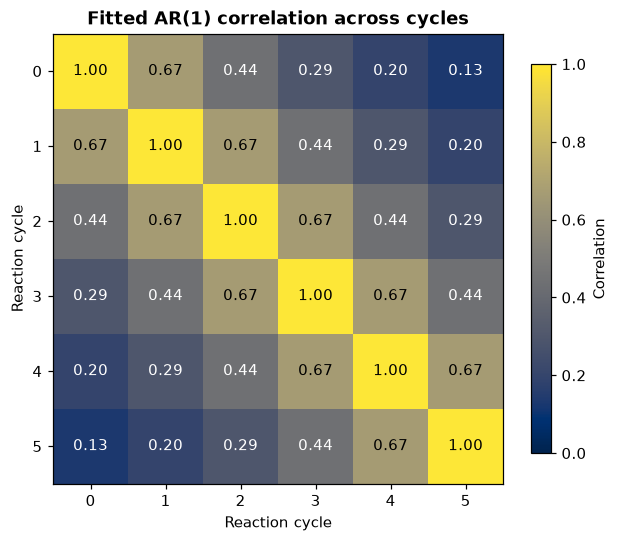

In [11]:
visit_standard_deviation = np.sqrt(np.diag(fitted_visit_covariance))
fitted_visit_correlation = (
    fitted_visit_covariance / visit_standard_deviation[:, None] / visit_standard_deviation[None, :]
)

fig, ax = plt.subplots(figsize=(5.8, 5.0))
image = ax.imshow(
    fitted_visit_correlation,
    cmap="cividis",
    vmin=0.0,
    vmax=1.0,
)
for row in range(len(cycle_levels)):
    for column in range(len(cycle_levels)):
        value = fitted_visit_correlation[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value < 0.55 else "black",
        )
ax.set_xticks(np.arange(len(cycle_levels)), labels=cycle_levels.astype(int))
ax.set_yticks(np.arange(len(cycle_levels)), labels=cycle_levels.astype(int))
ax.set_xlabel("Reaction cycle")
ax.set_ylabel("Reaction cycle")
ax.set_title("Fitted AR(1) correlation across cycles")
colorbar = fig.colorbar(image, ax=ax, shrink=0.82)
colorbar.set_label("Correlation")
fig.tight_layout()
plt.show()

**Interpretation.** Correlation is strongest on the diagonal and for adjacent
cycles, then decays smoothly with lag as specified by AR(1). The matrix remains
positive definite, as checked by the preceding assertions.

## 8. Inspect residual behavior over cycle

Averaging residuals by visit is a simple diagnostic. It does not replace
residual plots, influence checks, covariance sensitivity analysis, or
external validation.

In [12]:
print(f"{'cycle':>5s} {'mean residual':>15s} {'residual SD':>15s}")
for cycle_value in cycle_levels:
    selected = cycle == cycle_value
    cycle_residual = mmrm_fit.residuals[selected]
    print(
        f"{cycle_value:5.0f} "
        f"{float(np.mean(cycle_residual)):15.4f} "
        f"{float(np.std(cycle_residual, ddof=1)):15.4f}"
    )

cycle   mean residual     residual SD
    0          0.0056          1.7121
    1         -0.1997          1.7046
    2         -0.2124          1.8616
    3          0.4487          2.1540
    4          0.1057          1.9675
    5         -0.0532          1.6524


### Figure: residual distributions by reaction cycle

Cycle-specific boxplots reveal shifts, spread changes, and unusual residuals that a
table of means and standard deviations can miss.

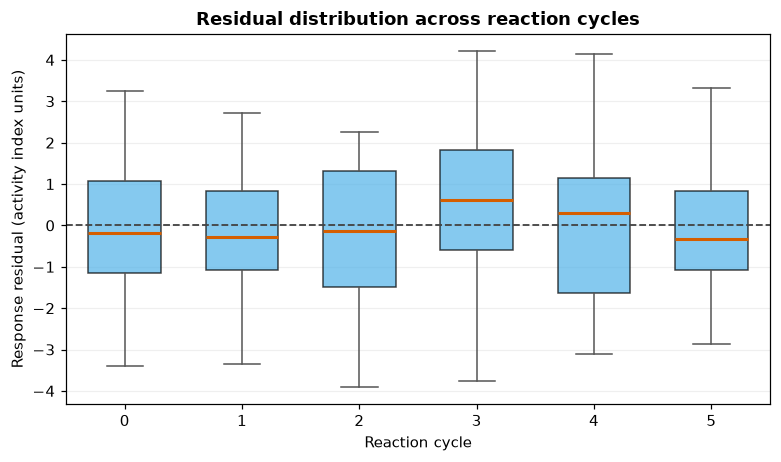

In [13]:
residual_by_cycle = [mmrm_fit.residuals[cycle == cycle_value] for cycle_value in cycle_levels]

fig, ax = plt.subplots(figsize=(7.2, 4.3))
boxplot = ax.boxplot(
    residual_by_cycle,
    patch_artist=True,
    widths=0.62,
    medianprops={"color": "#D55E00", "linewidth": 2.0},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#E69F00",
        "markeredgecolor": "#555555",
        "markersize": 4,
    },
)
for box in boxplot["boxes"]:
    box.set_facecolor("#56B4E9")
    box.set_alpha(0.72)
ax.axhline(0.0, color="#444444", linewidth=1.2, linestyle="--")
ax.set_xticks(
    np.arange(1, len(cycle_levels) + 1),
    labels=cycle_levels.astype(int),
)
ax.set_xlabel("Reaction cycle")
ax.set_ylabel("Response residual (activity index units)")
ax.set_title("Residual distribution across reaction cycles")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** Residual centers stay close to zero across cycles, with broadly
similar spreads in this realization. The figure supports, but does not replace,
covariance sensitivity and influence analysis.

## 9. Reproducibility record

The manifest and archived covariance-axis evidence make the analysis
auditable without implying regulatory qualification.

In [14]:
manifest = mmrm_fit.manifest.to_dict()
pprint(
    {
        "engine": manifest["engine"],
        "method": manifest["method"],
        "model_ir_hash": manifest["model_ir_hash"],
        "data_hash": manifest["data_hash"],
        "reproducibility_class": manifest["reproducibility_class"],
        "df_method": manifest["settings"]["df_method"],
        "visit_order_source": mmrm_fit.extra["visit_order_source"],
    }
)

{'data_hash': 'sha256:16d1d720d3a56ed0459fa3b8750dd1be70eb89a0d1a6e8a999687a616a73a58e',
 'df_method': 'satterthwaite',
 'engine': 'mmrm',
 'method': 'reml',
 'model_ir_hash': 'sha256:36b7c17e58256720f1069a0f95415b64d7dbfcf37356f41834674405b590bb0a',
 'reproducibility_class': 'deterministic-with-tolerance',
 'visit_order_source': 'ascending-explicit-visit-times'}


## Interpretation

The stabilized formulation has a less negative fitted activity slope in
this synthetic realization. The positive AR(1) estimate confirms that
nearby cycle measurements share residual information. The formulation
interaction, rather than the baseline difference alone, addresses the
deactivation-rate question.

A real study should report preplanned contrasts with their explicitly
labeled degrees-of-freedom method and should assess sensitivity to the
covariance structure.

## Scope note

This showcase focuses on linear mean trajectories, AR(1) covariance, and
explicitly labeled Satterthwaite inference. A deactivation program can
extend it with covariance and mean-curve sensitivity, an explicit
missingness rationale, preplanned contrasts, and physical diagnostics for
poisoning, sintering, fouling, or phase change so statistical conclusions
remain aligned with the experiment's limitations.

## Exercises

1. Replace AR(1) with `pymixef.covariance.Unstructured` and compare the
   estimated covariance, parameter count, and convergence.
2. Try Toeplitz covariance and explain how lag-specific correlation
   differs from AR(1) decay.
3. Remove late-cycle measurements from selected catalysts. Audit the
   exclusions and discuss whether missing at random is plausible.
4. Add a quadratic cycle term with `I(cycle_centered ** 2)` and inspect
   whether linear deactivation was adequate.
5. Permute the input rows and confirm that archived visit order and
   estimates remain invariant to numerical tolerance.

## Takeaways

- Repeated-measures covariance encodes scientific assumptions about
  within-unit dependence.
- Visit order must be explicit and auditable.
- Interpret formulation-by-cycle interaction as the slope difference.
- Check covariance positivity, convergence, and inference labels.
- Connect statistical trends back to mechanistic experiments.